In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import multivariate_normal
from scipy.linalg import expm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import random
SEED = 50
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

In [2]:
# Getting the market data

ticker = '^NSEI'  # For Nifty50
data = yf.download(ticker, start='2008-01-01', end='2026-05-31')['Close']

if isinstance(data, pd.DataFrame):
    data = data.squeeze()

data = data.dropna()
log_returns = pd.DataFrame({ticker: np.log(data / data.shift(1)).dropna()})

rets = log_returns[ticker].values
dates = log_returns.index

[*********************100%***********************]  1 of 1 completed


In [3]:
# Calculating Hurst Exponential using R/S rescaling method

def calc_hurst(ts):
    ts, N = np.asarray(ts), len(ts)
    if N < 20:
        return np.nan          # Because the number of observations has to be more than 20, Hurst exp do not work with very small sample sizes.

    lags = np.unique(np.logspace(np.log10(10), np.log10(N // 2), 10).astype(int))    # We are getting 10 equally spaced (in log scale) values between 10 and (N//2)

    log_rs, log_n = [], []     # This will store log(R/S) values and log(n) values


    for n in lags:             # We are looping through each scale

        blocks = ts[:N - N % n].reshape(-1, n)   # `N - N % n` ensures the remainder when `N/n` is removed so that we could easily create a matrix with `(N - N % n) / n` rows and n columns

        Z = np.cumsum(blocks - blocks.mean(axis=1, keepdims=True), axis=1)   # Here for each block, we subtract mean from the values to get fluctuations without mean.
                                                                             # Then we calculate the cumulative sum to see how these fluctuations behave sequentially.

        R = Z.max(axis=1) - Z.min(axis=1)  # R is range of the cumulative process of fluctuations

        S = blocks.std(axis=1, ddof=1)     # Standard deviation of fluctuations, to measure the typical fluctuation size

        valid = S > 0                      # To ensure division by zero do not happen

        if valid.any():
            log_rs.append(np.log((R[valid] / S[valid]).mean()))  # Average value of R/S across all blocks for the current scale n. We can say this is log[ mean(R/S) ]
            log_n.append(np.log(n))

    return np.polyfit(log_n, log_rs, 1)[0] if len(log_n) > 2 else np.nan  # We regress E[log(R/S)] as a function of log(n) and get the slope value

In [4]:
# Calculating Largest Lyapunov Exponent

'''
LLE is being applied over log returns and as this time series is theoretically an IID (efficient market hypothesis) and independent from the previous values, therefore LLE will always be
more than 0. The distinction between `Complete Chaos Regime` and `Boundary of Chaos and Persistence Regime` is defined using the magnitude of LLE.
'''

# We estimate Theiler so that we avoid picking two consecutive values in a time series. Theiler window is our no-go window. This is crucial for clustering in a time series data.
# We tell the KDTree algorithms to not consider values in this window.

def estimate_theiler(ts, default_n = 10):

    ts_c = ts - ts.mean()        # We remove the mean from all values to see the deviations (fluctuations), mean centered data

    var = np.var(ts_c, ddof=1)   # Finding variance of the mean centered data

    if var == 0:
        return default_n         # If there is zero variance, pick values that are `default_n` timestamps apart

    for lag in range(1, min(20, len(ts) - 1)):
        autocorrelation = np.dot(ts_c[:-lag], ts_c[lag:]) / ((len(ts) - 1) * var)
        if  autocorrelation <= 0:      # The moment autocorrelation becomes zero or negative is where the linear relationship breaks.
                                       # So now this becomes a safe zone for clustering algo to work on.
            return max(2, lag)
    return default_n


def calc_lyapunov(ts, m=3, tau=1, traj_len=10):

  # m is embedding dimension. Dimension of the vector that will represent the state space. We will use m=3 by default as this can help us capture more dimensions.
  # tau is delay in timestamps. For instance, [ x[i], x[i + tau], x[i + 2*tau], . . . , x[i + (m - 1) * tau] ]
  # traj_len is the future steps we follow

  # Delay Embedding (Taken's Theorem)

    ts = np.asarray(ts)
    emb_len = len(ts) - (m - 1) * tau   # Embedding Length = `Length of Time Series` - `Count of elements in defined state space`. This is the count of complete vectors we can build.

    if emb_len < traj_len + 5:          # To few possible vectors and the entire process is statistically useless. So we should have a good enough number of complete vectors to begin with.
        return np.nan

    X = np.array([ts[i:i + (m - 1) * tau + 1:tau] for i in range(emb_len)])  # Creating len(embedding length) number of vectors with length `(m-1) * tau`


    tree = KDTree(X)
    theiler = estimate_theiler(ts)      # Finding Theiler window for given time series

    divergence = np.zeros(traj_len)
    count     = np.zeros(traj_len, dtype=int)

    for i in range(emb_len - traj_len): # Looping over ts until we have the last usable data

        _, idxs = tree.query(X[i], k=min(20, emb_len))  # We are finding 20 nearest vectors to a given vector X[i]
        nn = next((
                j for j in idxs         # Looping over all nearest vectors found
             if abs(i - j) > theiler    # Checking if `|i - j| > W` holds true
             and
             j + traj_len < emb_len     # Only loop over data points within last usable range
                ),-1)

        if nn == -1:                    # If no nearest neighbour exists, skip this entire loop
            continue
        d     = np.linalg.norm(X[i:i + traj_len] - X[nn:nn + traj_len], axis=1)   # Compute Euclidean distance between two relevant data points

        valid = d > 1e-10               # If the distance is more than an allowed minimum value of 1e-10, only then it is considered valid

        divergence[valid] += np.log(d[valid])  # Calculating log(d0)
        count[valid]      += 1

    valid = count > 0
    if valid.sum() < 3:
        return np.nan
    return float(np.polyfit(np.arange(traj_len)[valid],
                            divergence[valid] / count[valid], 1)[0])  # Fitting a linear regression and finding it slope, which is out lambda.

In [5]:
# Calculating Sample Entropy (SampEn)

def calc_sampen(ts, m=2, r_mult=0.2):

  # ts is the time series
  # m is the 'template length' or the length of continuous data that we measure
  # r_mult is our 'tolerance level' or to say of two series are within r_mult*sigma, then we consider them

    ts, N = np.asarray(ts, dtype=float), len(ts)
    r = r_mult * ts.std(ddof=1)                   # Calculating r = r_mult * sigma(time_series)
    if r == 0:
        return np.nan

    def count_matches(dim):
        templates = np.lib.stride_tricks.sliding_window_view(ts, dim)[:-1]   # Creating sliding window templates of length 'm'
        dist = np.abs(templates[:, None] - templates[None, :]).max(axis=2)   # Computing pair-wise distance between all elements of the pairs, and take the max of it (Chebyshev distance)
        np.fill_diagonal(dist, np.inf)                                       # Removing distances of an element with itself
        return (dist <= r).sum()

    B, A = count_matches(m), count_matches(m + 1)                            # Count matching entropy series with m and m+1 lengths
    return -np.log(A / B) if B > 0 and A > 0 else np.nan                     # Return -log[A / B]

In [6]:
# Lag-1 Autocorrelation Calculation

def calc_rho(s):
    n = len(s)
    if n < 2: return np.nan
    mu = np.mean(s)
    cov = np.sum((s[:-1] - mu) * (s[1:] - mu)) / (n - 1)
    var = np.var(s, ddof=1)
    if var == 0: return np.nan
    return cov / var

In [7]:
window_h   = 252       # Window for Hurst Exponent
window_s   = 120       # Window for Lyapunov, Samplen and Autocorrelation
stride     = 5         # Calculating after 5 days


res_df = pd.DataFrame(
    [{'Date':   dates[i - 1],
      'H':      calc_hurst(rets[i - window_h : i]),
      'Lyap':   calc_lyapunov(w := rets[i - window_s : i]),
      'SampEn': calc_sampen(w),
      'Rho':    calc_rho(w)}
     for i in range(window_h, len(dates), stride)]
).set_index('Date').dropna()


Training Diagnostics (2010–2020)
          Mean     Std  5th Pct  95th Pct
H       0.5920  0.0420   0.5253    0.6575
Lyap    0.1204  0.0127   0.1007    0.1415
SampEn  2.1042  0.3582   1.5849    2.7207
Rho     0.0493  0.0886  -0.1115    0.1767


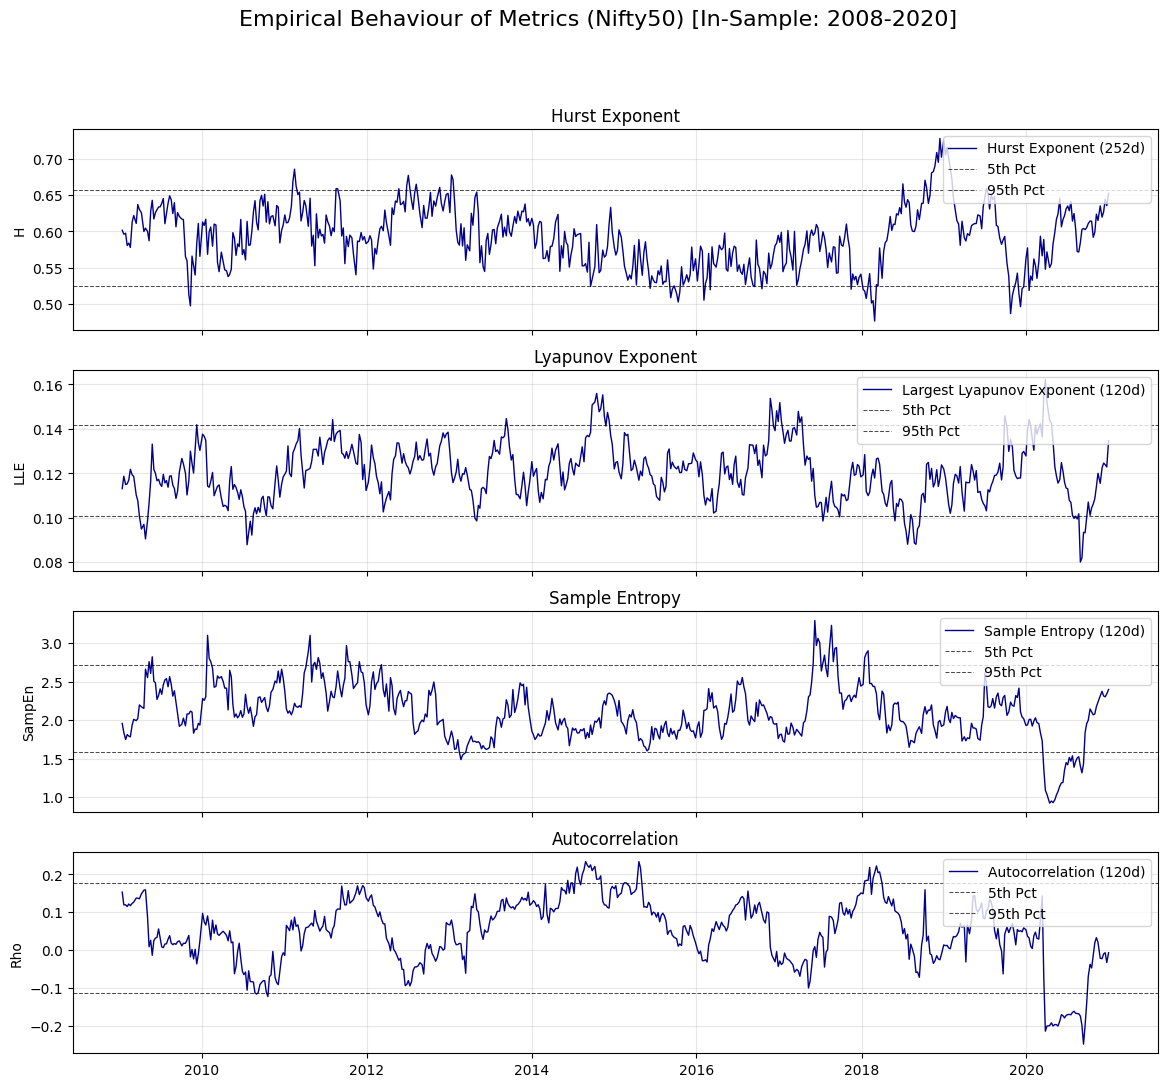

In [8]:
data_cols = ['H', 'Lyap', 'SampEn', 'Rho']

# --- Split ---
Y_train = res_df.loc[:'2020-12-31', data_cols]
Y_test  = res_df.loc['2021-07-01':, data_cols]        # We are leaving 6 months of data as an embargo period

# --- Diagnostics: one DataFrame operation replaces the print loop ---
stats = pd.concat([Y_train.mean(), Y_train.std(),
                   Y_train.quantile(0.05), Y_train.quantile(0.95)],
                  axis=1, keys=['Mean', 'Std', '5th Pct', '95th Pct'])
print(f"\nTraining Diagnostics (2010–2020)\n{stats.round(4).to_string()}")


res_df_is = res_df.loc[:'2020-12-31']

fig_metrics, axes_metrics = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig_metrics.suptitle('Empirical Behaviour of Metrics (Nifty50) [In-Sample: 2008-2020]', fontsize=16)

# 1. Hurst Exponent
axes_metrics[0].plot(res_df_is.index, res_df_is['H'], label='Hurst Exponent (252d)', color='darkblue', linewidth=1)
axes_metrics[0].set_ylabel('H')
axes_metrics[0].set_title('Hurst Exponent')
axes_metrics[0].grid(True, alpha=0.3)
axes_metrics[0].axhline(res_df_is['H'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[0].axhline(res_df_is['H'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[0].legend(loc='upper right')

# 2. Lyapunov Exponent
axes_metrics[1].plot(res_df_is.index, res_df_is['Lyap'], label='Largest Lyapunov Exponent (120d)', color='darkblue', linewidth=1)
axes_metrics[1].set_ylabel('LLE')
axes_metrics[1].axhline(res_df_is['Lyap'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[1].axhline(res_df_is['Lyap'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[1].set_title('Lyapunov Exponent')
axes_metrics[1].legend(loc='upper right')
axes_metrics[1].grid(True, alpha=0.3)

# 3. Sample Entropy
axes_metrics[2].plot(res_df_is.index, res_df_is['SampEn'], label='Sample Entropy (120d)', color='darkblue', linewidth=1)
axes_metrics[2].set_ylabel('SampEn')
axes_metrics[2].axhline(res_df_is['SampEn'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[2].axhline(res_df_is['SampEn'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[2].set_title('Sample Entropy')
axes_metrics[2].legend(loc='upper right')
axes_metrics[2].grid(True, alpha=0.3)

# 4. Autocorrelation
axes_metrics[3].plot(res_df_is.index, res_df_is['Rho'], label='Autocorrelation (120d)', color='darkblue', linewidth=1)
axes_metrics[3].set_ylabel('Rho')
axes_metrics[3].axhline(res_df_is['Rho'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[3].axhline(res_df_is['Rho'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[3].set_title('Autocorrelation')
axes_metrics[3].legend(loc='upper right')
axes_metrics[3].grid(True, alpha=0.3)

plt.show()

In [9]:
K = 3  # We are taking 3 clusters because we want to classify these metrics into 3 different regimes

# Running K-means on training data (after Standardizing the data)
train_labels = KMeans(n_clusters=K, random_state=SEED).fit_predict(
    StandardScaler().fit_transform(Y_train)
)

# Sort clusters by Hurst ascending.
# State 0 = lowest H
# State 1 = middle H
# State 2 = highest H

order = np.argsort([Y_train.values[train_labels == k, 0].mean()
                    for k in range(K)])

train_rets = log_returns[ticker].loc[Y_train.index]            # Filter all returns that matches the Y_train index
global_mu, global_vol = train_rets.mean(), train_rets.std()    # Finding mean and standard deviation of training returns

Means, Covs, mu_estimates, vol_estimates = [], [], [], []
for old_k in order:
    mask     = train_labels == old_k
    obs      = Y_train.values[mask]
    rets_k   = train_rets.loc[Y_train.index[mask]]
    sufficient = len(rets_k) >= 20

    Means.append(obs.mean(axis=0))
    Covs.append(np.cov(obs.T) + 1e-6 * np.eye(len(data_cols)))                            # We are adding `1e-16 + np.eye(len(data_cols))` to ensure numerical stability
    mu_estimates.append(rets_k.mean() if sufficient else global_mu)
    vol_estimates.append(rets_k.std()  if sufficient else global_vol)

Means         = np.array(Means)                        # Means contain average values for all metrics for all three regimes
mu_estimates  = np.array(mu_estimates)
vol_estimates = np.array(vol_estimates)

In [10]:
def estimate_generator_Q(labels, stride=5, regularise=1e-3):
    """
    Estimate the continuous-time Markov generator Q from
    a sequence of discrete state labels using MLE.

    Parameters
    ----------
    labels  : 1D array of integer state assignments (from K-means)
    stride  : observation interval in trading days
              (matches the stride used in the rolling window)
    regularise : small constant added to off-diagonal counts
                 to prevent zero transition rates

    Returns
    -------
    Q : (K, K) generator matrix with rows summing to zero
    """
    K = len(np.unique(labels))           # Counting the number of unique regimes

    # Count transitions between consecutive observations
    # Labels are spaced 'stride' days apart in calendar time
    N = np.zeros((K, K))                 # K x K matrix with zeroes
    for t in range(len(labels) - 1):     # Counting the frequency of regime transitions for each combination
        i, j = labels[t], labels[t + 1]
        N[i, j] += 1

    # Time spent in each state (in units of stride days)
    T = np.array([np.sum(labels == k) * stride for k in range(K)],
                 dtype=float)                                       # Converting transition matrix units from strides to actual trading days

    # MLE: q_ij = N_ij / T_i for i != j
    Q_est = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            if i != j:
                # Regularise to avoid zero rates for unseen transitions
                Q_est[i, j] = (N[i, j] + regularise) / T[i]              # Instantaneous Rate of Transition = Count of Transition[regime i -> regime j] / Count of days in regime i

    # Diagonal: rows must sum to zero
    np.fill_diagonal(Q_est, -Q_est.sum(axis=1))

    return Q_est

In [11]:
# --- Estimate Q from training labels (replaces hardcoded matrix) ---
remapped = np.array([np.where(order == k)[0][0] for k in train_labels])
Q = estimate_generator_Q(remapped, stride=stride)

# --- Print results ---
state_names = ['State 0 (Equilibrium Reverting)',
               'State 1 (Complete Chaos)',
               'State 2 (Edge of Chaos)']
print("\n--- Emission Means (Sorted by Hurst) |[H        Lyap      SampEn     Rho   ] ---")
print(f"                             State 0: [{np.round(Means[0][0],4)}   {np.round(Means[0][1],4)}    {np.round(Means[0][2],4)}     {np.round(Means[0][3],4)}]")
print(f"                             State 1: [{np.round(Means[1][0],4)}   {np.round(Means[1][1],4)}    {np.round(Means[1][2],4)}     {np.round(Means[1][3],4)}]")
print(f"                             State 2: [{np.round(Means[2][0],4)}   {np.round(Means[2][1],4)}    {np.round(Means[2][2],4)}    {np.round(Means[2][3],4)}]")


print("\n\nHurst:-    " + " | ".join(f"State{k}: {Means[k, 0]:.4f}" for k in range(K)))

if (Means[:, 0] > 0.48).all():
    print("\n[EMPIRICAL FINDING] All states show H > 0.48 on 252-day windows. "
          "Anti-persistence undetectable at this timescale. "
          "Consider 120+ days windows for Lyapunov and SampEn.")

print(f"\n--- Training Return Statistics ---")
print(f"Mu  (Daily): {mu_estimates.round(6)}")
print(f"Vol (Daily): {vol_estimates.round(6)}")
print(f"\n--- Estimated Q Matrix ---\n{np.round(Q, 6)}")


--- Emission Means (Sorted by Hurst) |[H        Lyap      SampEn     Rho   ] ---
                             State 0: [0.5667   0.1289    1.9201     0.0766]
                             State 1: [0.5874   0.1154    2.4552     0.0883]
                             State 2: [0.6297   0.1142    1.9832    -0.0271]


Hurst:-    State0: 0.5667 | State1: 0.5874 | State2: 0.6297

[EMPIRICAL FINDING] All states show H > 0.48 on 252-day windows. Anti-persistence undetectable at this timescale. Consider 120+ days windows for Lyapunov and SampEn.

--- Training Return Statistics ---
Mu  (Daily): [-0.000421 -0.000202  0.00211 ]
Vol (Daily): [0.011644 0.011273 0.011266]

--- Estimated Q Matrix ---
[[-0.026958  0.014783  0.012175]
 [ 0.018786 -0.034256  0.015471]
 [ 0.016001  0.014858 -0.030859]]


In [12]:
# Implied mean sojourn time in each state (in trading days). How long a regime stays
sojourn_days = -1.0 / np.diag(Q)


state_names = ['State 0', 'State 1', 'State 2']

print("\n--- Implied Mean Regime Duration ---")

for k, (name, days) in enumerate(zip(state_names, sojourn_days)):
    print(f"  {name}: {days:.1f} trading days ")


--- Implied Mean Regime Duration ---
  State 0: 37.1 trading days 
  State 1: 29.2 trading days 
  State 2: 32.4 trading days 


In [13]:
# Out-of-Sample Discrete-time HMM forward filter

def hmm_forward_filter(Y_test, Means, Covs, Q, span=15):
    """
    Discrete-time HMM forward filter (Hamilton filter).
    Approximates a continuous-time Wonham filter via P = expm(Q).

    Parameters
    ----------
    Y_test : pd.DataFrame of shape (T, n_features)
    Means  : list of K mean vectors
    Covs   : list of K covariance matrices
    Q      : (K, K) infinitesimal generator matrix
    span   : EMA smoothing span

    Returns
    -------
    pi_smooth : pd.DataFrame of smoothed posterior probabilities
    """
    P = expm(Q)             # Probability = matrix_exponential(Q)
    K = len(Means)
    Y = Y_test.values

    # Precompute all emission likelihoods at once — shape (T, K)
    L = np.column_stack([
        multivariate_normal(mean=Means[k], cov=Covs[k],
                            allow_singular=True).pdf(Y)
        for k in range(K)
    ])                                                     # Multivariate Gaussian PDF evaluated at each observation


    L = np.clip(L, 1e-300, None)   # Numerical floor prevents underflow

    # Forward pass: sequential by necessity (each step depends on previous)
    pi = np.empty((len(Y), K))
    pi[0] = 1.0 / K                # uniform prior

    for t in range(1, len(Y)):
        predicted = pi[t - 1] @ P
        unnorm    = predicted * L[t]
        total     = unnorm.sum()
        pi[t]     = unnorm / total if total > 1e-300 else predicted

    cols = ['Prob_State0', 'Prob_State1', 'Prob_State2']
    pi_df = pd.DataFrame(pi, index=Y_test.index, columns=cols)
    return pi_df.ewm(span=span, adjust=False).mean()


pi_df_smooth  = hmm_forward_filter(Y_test, Means, Covs, Q, span=15)
pi_t_smooth   = pi_df_smooth.values

In [14]:
# Dynamic Portfolio Allocation & Backtest

T_len = len(Y_test)
weights = np.zeros(T_len)
target_vol = 0.01  # Daily target volatility

for t in range(T_len):
    E_mu = np.dot(pi_t_smooth[t], mu_estimates)        # E[Return] = regime_prob * past_regime_returns
    E_var = np.dot(pi_t_smooth[t], vol_estimates**2)   # E[Var]    = regime_prob * (past_regime_volatility ** 2)
    if E_var < 1e-10: E_var = 1e-10

    E_daily_vol = np.sqrt(E_var)

    w_myopic = (target_vol / E_daily_vol) * np.sign(E_mu)   # (target_vol / E[vol]) * (sign of E[Return])
    # This step adjusts the weights to target the given volatility. Increases exposure when vol is less. Decrease exposure (hold more cash) when vol is more.


    # State1 is the regime of total chaos. This is where we hedge and protect our wealth
    if t > 0:
        dP_State1 = pi_t_smooth[t, 1] - pi_t_smooth[t-1, 1]   # dP[State1] = Prob[State1, t = t] - Prob[State1, t = t-1]
    else:
        dP_State1 = 0

    hedge_sensitivity = -0.90                                # Calibrated to give desired drawdawn protection
    w_hedge = hedge_sensitivity * max(dP_State1, 0)          # dP[State1] is +ve, we need to hedge

    weights[t] = np.clip(w_myopic + w_hedge, 0.0, 1)         # We are keeping an unleveraged portfolio



# Build a weights series on strided rebalance dates
weights_series = pd.Series(weights, index=Y_test.index)

# Get ALL daily returns for the test period
all_test_returns = log_returns[ticker].loc[
    Y_test.index[0] : Y_test.index[-1]
].dropna()

# Forward-fill regime weights to every trading day
weights_daily = weights_series.reindex(
    all_test_returns.index, method='ffill'
).fillna(0)

# Lag weights by 1 day to avoid look-ahead bias
strategy_rets = weights_daily.shift(1) * all_test_returns
strategy_rets = strategy_rets.dropna()
bnh_rets = all_test_returns.loc[strategy_rets.index]

cum_strat = np.exp(np.cumsum(strategy_rets))
cum_bnh = np.exp(np.cumsum(bnh_rets))

cum_strat = cum_strat / cum_strat.iloc[0]
cum_bnh = cum_bnh / cum_bnh.iloc[0]


       Performance Summary [Out-of-Sample: 2021-2026]       
Metric                    | Strategy        | Buy & Hold     
------------------------------------------------------------
Annualised Return         |          8.87% |          8.54%
Annualised Sharpe         |           1.05 |           0.62
Max Drawdown              |        -10.34% |        -17.23%
Calmar Ratio              |           0.86 |           0.50

Out-of-Sample Regime Distribution (Smoothed):
  Prob_State0: 23.55%
  Prob_State1: 38.84%
  Prob_State2: 37.60%


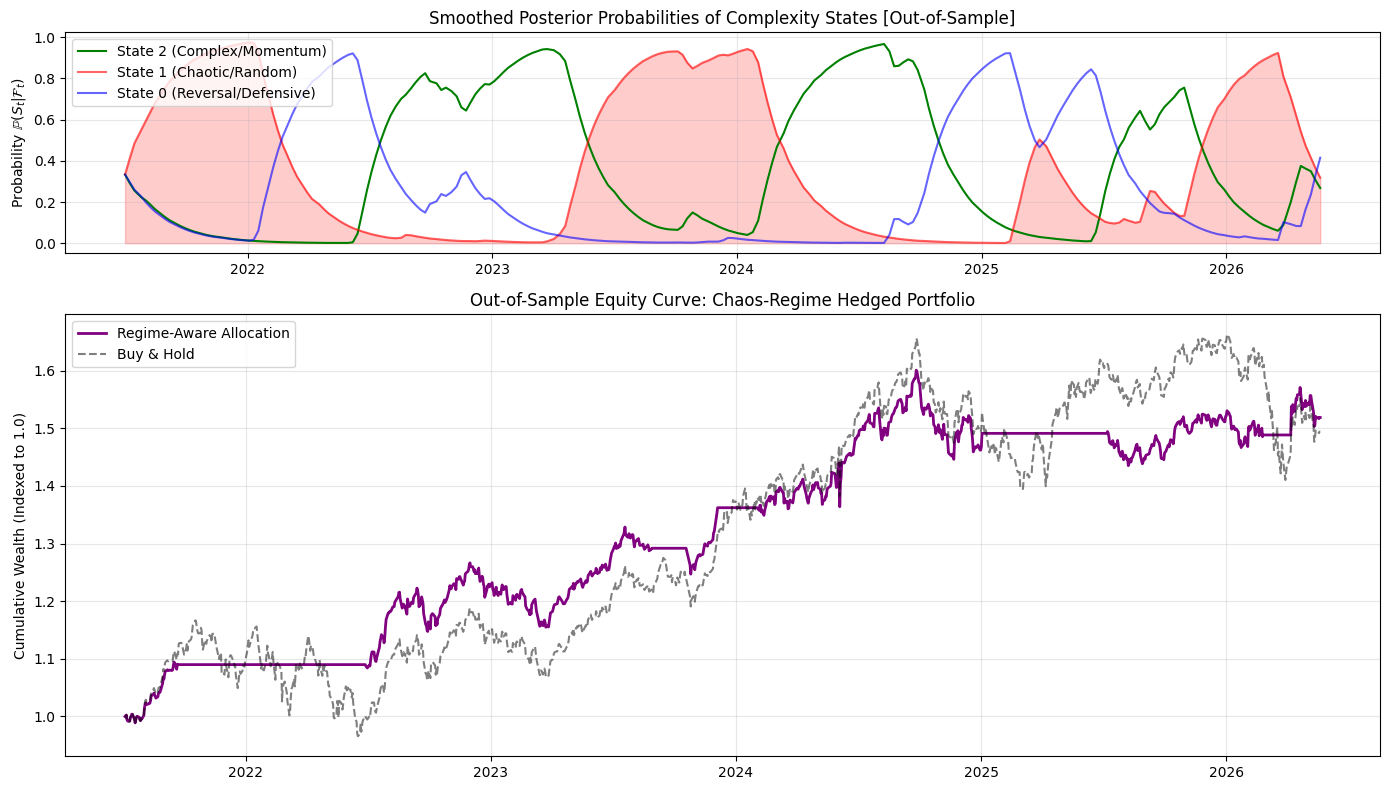

In [15]:
# Performance Summary & Visualizations

ann_ret_strat = strategy_rets.mean() * 252
ann_ret_bnh = bnh_rets.mean() * 252

ann_vol_strat = strategy_rets.std() * np.sqrt(252)
ann_vol_bnh = bnh_rets.std() * np.sqrt(252)

ann_sharpe_strat = ann_ret_strat / ann_vol_strat if ann_vol_strat != 0 else 0
ann_sharpe_bnh = ann_ret_bnh / ann_vol_bnh if ann_vol_bnh != 0 else 0

mdd_strat = (cum_strat / cum_strat.cummax() - 1.0).min()
mdd_bnh = (cum_bnh / cum_bnh.cummax() - 1.0).min()

calmar_strat = ann_ret_strat / abs(mdd_strat) if mdd_strat != 0 else 0
calmar_bnh = ann_ret_bnh / abs(mdd_bnh) if mdd_bnh != 0 else 0

dist = pi_df_smooth.idxmax(axis=1).value_counts(normalize=True) * 100

print("\n" + "="*60)
print(f"{'Performance Summary [Out-of-Sample: 2021-2026]':^60}")
print("="*60)
print(f"{'Metric':<25} | {'Strategy':<15} | {'Buy & Hold':<15}")
print("-" * 60)
print(f"{'Annualised Return':<25} | {ann_ret_strat:>14.2%} | {ann_ret_bnh:>14.2%}")
print(f"{'Annualised Sharpe':<25} | {ann_sharpe_strat:>14.2f} | {ann_sharpe_bnh:>14.2f}")
print(f"{'Max Drawdown':<25} | {mdd_strat:>14.2%} | {mdd_bnh:>14.2%}")
print(f"{'Calmar Ratio':<25} | {calmar_strat:>14.2f} | {calmar_bnh:>14.2f}")
print("=" * 60)

print("\nOut-of-Sample Regime Distribution (Smoothed):")
for col in pi_df_smooth.columns:
    val = dist.get(col, 0.0)
    print(f"  {col}: {val:.2f}%")

if dist.get('Prob_State1', 0.0) > 80.0:
    print("\n[DIAGNOSTIC WARNING] State 1 (Chaos) still dominating above 80%.")
    print("Checking early test sample metrics:")
    print(Y_test.head(10))

# --- PLOT 1: Regime Probabilities & Portfolio Performance ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]}, sharex=False)

axes[0].plot(pi_df_smooth.index, pi_df_smooth['Prob_State2'], label='State 2 (Complex/Momentum)', color='green')
axes[0].plot(pi_df_smooth.index, pi_df_smooth['Prob_State1'], label='State 1 (Chaotic/Random)', color='red', alpha=0.6)
axes[0].plot(pi_df_smooth.index, pi_df_smooth['Prob_State0'], label='State 0 (Reversal/Defensive)', color='blue', alpha=0.6)
axes[0].fill_between(pi_df_smooth.index, 0, pi_df_smooth['Prob_State1'], color='red', alpha=0.2)
axes[0].set_title('Smoothed Posterior Probabilities of Complexity States [Out-of-Sample]')
axes[0].set_ylabel('Probability $\mathbb{P}(S_t | \mathcal{F}_t)$')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cum_strat.index, cum_strat, label='Regime-Aware Allocation', color='purple', linewidth=2)
axes[1].plot(cum_bnh.index, cum_bnh, label='Buy & Hold', color='black', alpha=0.5, linestyle='--')
axes[1].set_title('Out-of-Sample Equity Curve: Chaos-Regime Hedged Portfolio')
axes[1].set_ylabel('Cumulative Wealth (Indexed to 1.0)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

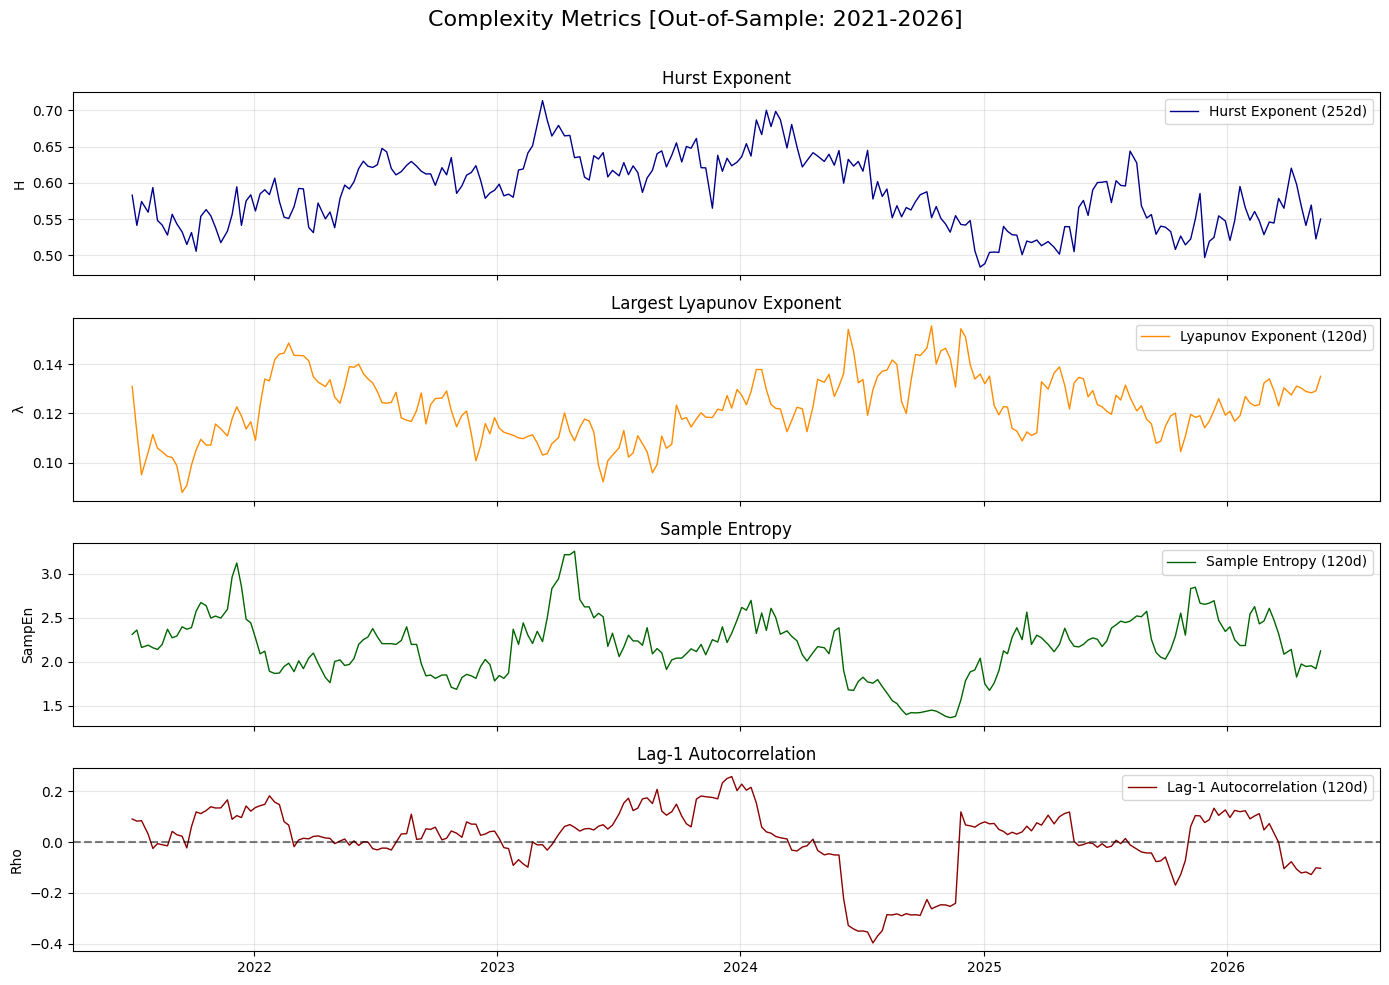

In [16]:
# --- PLOT 2: The 4 Mathematical Metrics over Time ---
# Filter the results dataframe to only plot data from 2021 onwards
res_df_oos = res_df.loc['2021-07-01':]

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig2.suptitle('Complexity Metrics [Out-of-Sample: 2021-2026]', fontsize=16)

# 1. Hurst Exponent
axes2[0].plot(res_df_oos.index, res_df_oos['H'], label='Hurst Exponent (252d)', color='darkblue', linewidth=1)
axes2[0].set_ylabel('H')
axes2[0].set_title('Hurst Exponent')
axes2[0].legend(loc='upper right')
axes2[0].grid(True, alpha=0.3)

# 2. Lyapunov Exponent
axes2[1].plot(res_df_oos.index, res_df_oos['Lyap'], label='Lyapunov Exponent (120d)', color='darkorange', linewidth=1)
axes2[1].set_ylabel('λ')
axes2[1].set_title('Largest Lyapunov Exponent')
axes2[1].legend(loc='upper right')
axes2[1].grid(True, alpha=0.3)

# 3. Sample Entropy
axes2[2].plot(res_df_oos.index, res_df_oos['SampEn'], label='Sample Entropy (120d)', color='darkgreen', linewidth=1)
axes2[2].set_ylabel('SampEn')
axes2[2].set_title('Sample Entropy')
axes2[2].legend(loc='upper right')
axes2[2].grid(True, alpha=0.3)

# 4. Lag-1 Autocorrelation
axes2[3].plot(res_df_oos.index, res_df_oos['Rho'], label='Lag-1 Autocorrelation (120d)', color='darkred', linewidth=1)
axes2[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes2[3].set_ylabel('Rho')
axes2[3].set_title('Lag-1 Autocorrelation')
axes2[3].legend(loc='upper right')
axes2[3].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97]) # Prevents subplots from overlapping the suptitle
plt.show()